In [42]:
import torch
from torchvision import models, transforms
import torch
import typing
import numpy as np
import cv2

In [74]:
model = models.segmentation.deeplabv3_mobilenet_v3_large(pretrained=True)

c:\Users\524ha\anaconda3\envs\seg\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\524ha\anaconda3\envs\seg\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_MobileNet_V3_Large_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [75]:
model.eval()  # parantezi unutmayın
# 1) oku (BGR), RGB'ye çevir
img_bgr = cv2.imread(r"C:\Users\524ha\Desktop\Resources\BasketballGameTracker\dog.jpg", cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  # shape (H, W, 3)

# 2a) torchvision kullanarak
preprocess = transforms.Compose([
    transforms.ToTensor(),  # -> tensor [3, H, W], float in [0,1]
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
input_tensor = preprocess(Image.fromarray(img_rgb))  # torch.Tensor [3, H, W]
input_batch = input_tensor.unsqueeze(0)               # [1, 3, H, W]
print("torch input_batch.shape:", input_batch.shape)

# 2b) veya doğrudan numpy -> torch (aynı sonuca eşdeğer)
t = torch.from_numpy(img_rgb).permute(2,0,1).float().div(255.0)  # [3,H,W]
t = transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])(t)
print("torch t.shape:", t.shape)

with torch.no_grad():
    outputs = model(input_batch)            # outputs bir dict: 'out' (ve varsa 'aux')
logits = outputs['out']    

pred = torch.argmax(logits.squeeze(), dim=0).cpu().numpy()  # shape: (H, W)
print("Mask shape:", pred.shape)         

torch input_batch.shape: torch.Size([1, 3, 576, 768])
torch t.shape: torch.Size([3, 576, 768])
Mask shape: (576, 768)


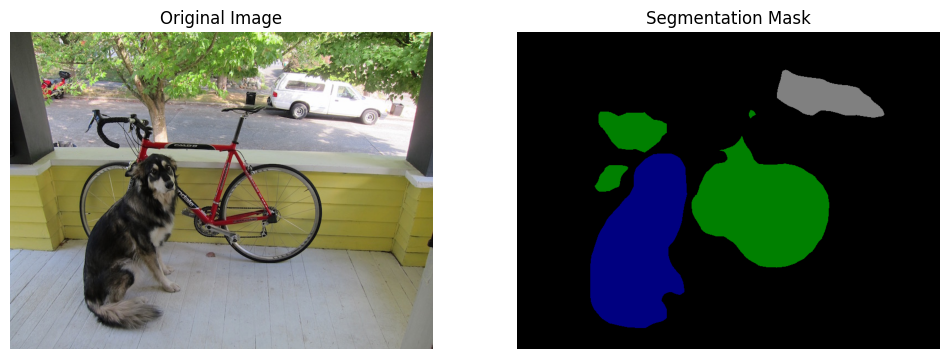

In [76]:
import matplotlib.pyplot as plt

# Basit bir renk tablosu tanımlayalım (isteğe göre genişletilebilir)
colors = np.array([
    [0, 0, 0],         # 0 - background (siyah)
    [128, 0, 0],       # 1 - class1
    [0, 128, 0],       # 2 - class2
    [128, 128, 0],     # 3 - class3
    [0, 0, 128],       # 4 - class4
    [128, 0, 128],     # 5 - class5
    [0, 128, 128],     # 6 - class6
    [128, 128, 128]    # 7 - class7
], dtype=np.uint8)

# pred maskesini renklendir
color_mask = colors[pred % len(colors)]  # (H, W, 3)

# Eğer OpenCV görüntünü kullanmak istersen:
img_rgb_resized = cv2.resize(img_rgb, (color_mask.shape[1], color_mask.shape[0]))

# Görüntüleri yan yana göster
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb_resized)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(color_mask)
plt.title("Segmentation Mask")
plt.axis('off')

plt.show()


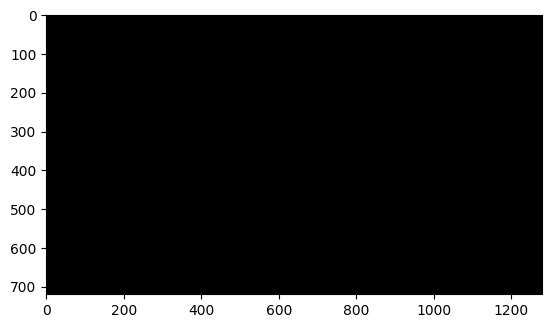

In [41]:
   # outputs bir dict: 'out' (ve varsa 'aux')

logits = scores['out']                    # shape [N, C, H, W]
pred = torch.argmax(logits, dim=1)         # shape [N, H, W]
mask = pred[0].cpu().numpy().astype('uint8')# tek görüntü için [H, W]

# Basit renklendirme örneği
num_classes = logits.shape[1]
palette = (np.arange(num_classes) * 123457) % 255
colors = np.stack([palette, palette//2, palette//3], axis=1).astype(np.uint8)
colored = colors[mask]                    # [H, W, 3] (RGB)

import matplotlib.pyplot as plt
plt.imshow(colored)